In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('data/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

data/train.parquet
data/test.parquet
data/target_channels.csv
data/sample_submission.parquet
data/preprocessed/datasets.csv


In [2]:
# Load all channels and show stats
train_df = pd.read_parquet("data/train.parquet")
channel_names = [x for x in train_df.columns if x not in ["id", "is_anomaly"]]
train_df[channel_names].describe()

,channel_1,channel_10,channel_11,channel_12,channel_13,channel_14,channel_15,channel_16,channel_17,channel_18,...,telecommand_350,telecommand_351,telecommand_352,telecommand_353,telecommand_354,telecommand_36,telecommand_376,telecommand_38,telecommand_39,telecommand_40
count,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,...,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07
mean,1.380301e-01,6.403504e-09,4.395080e-10,2.557318e-01,3.094885e-01,2.720448e-01,1.210223e-01,7.610638e-01,2.927625e-01,3.147995e-01,...,3.802198e-06,1.629514e-06,1.765306e-06,1.901099e-06,1.901099e-06,4.481163e-06,3.123234e-06,2.376374e-06,2.580063e-06,2.580063e-06
std,4.428727e-03,1.492817e-06,2.467632e-07,5.158953e-02,5.081466e-02,9.578262e-02,6.525146e-02,7.655781e-02,5.072071e-02,4.922460e-02,...,1.949919e-03,1.276523e-03,1.328647e-03,1.378802e-03,1.378802e-03,2.116871e-03,1.767265e-03,1.541547e-03,1.606256e-03,1.606256e-03
min,9.217216e-02,0.000000e+00,0.000000e+00,1.225953e-01,1.721236e-01,7.845081e-02,1.286942e-03,7.355139e-03,1.422070e-01,1.659085e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.379103e-01,0.000000e+00,0.000000e+00,2.126752e-01,2.672639e-01,2.142259e-01,7.987051e-02,7.042502e-01,2.499678e-01,2.755977e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.379103e-01,0.000000e+00,0.000000e+00,2.547867e-01,3.078156e-01,2.594865e-01,1.185188e-01,7.612530e-01,2.906744e-01,3.132904e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.379103e-01,0.000000e+00,0.000000e+00,2.953383e-01,3.483671e-01,3.062542e-01,1.520136e-01,8.237714e-01,3.328890e-01,3.509814e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,4.331867e-01,4.236102e-04,4.218630e-04,9.967715e-01,9.919286e-01,9.710565e-01,5.413337e-01,9.140906e-01,9.843958e-01,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [3]:
# Limit to channels 41-52
channel_names = [f"channel_{x}" for x in range(41,52 + 1)]
train_df[channel_names].describe()

,channel_41,channel_42,channel_43,channel_44,channel_45,channel_46,channel_47,channel_48,channel_49,channel_50,channel_51,channel_52
count,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07,1.472832e+07
mean,8.082077e-01,7.821209e-01,7.685694e-01,7.940099e-01,8.103804e-01,7.656219e-01,2.706180e-03,2.762995e-03,2.716671e-03,7.511101e-01,7.749832e-01,7.555029e-01
std,3.117312e-02,3.104107e-02,3.194150e-02,3.466514e-02,3.144005e-02,3.055148e-02,3.027458e-02,3.027286e-02,3.027426e-02,4.047560e-02,4.156856e-02,4.126789e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.658259e-05,4.229407e-05,0.000000e+00,2.132649e-02,2.042981e-02,0.000000e+00
25%,8.055143e-01,7.783114e-01,7.663610e-01,7.913063e-01,8.066803e-01,7.610731e-01,1.765810e-03,1.824006e-03,1.775930e-03,7.427393e-01,7.671894e-01,7.469911e-01
50%,8.094388e-01,7.831301e-01,7.703173e-01,7.960299e-01,8.117668e-01,7.669848e-01,1.788585e-03,1.846781e-03,1.798705e-03,7.523080e-01,7.767581e-01,7.565598e-01
75%,8.141486e-01,7.895566e-01,7.742736e-01,8.007520e-01,8.168547e-01,7.728950e-01,1.821481e-03,1.877141e-03,1.831601e-03,7.661285e-01,7.895136e-01,7.703804e-01
max,9.821104e-01,9.662727e-01,9.507276e-01,9.755059e-01,1.000000e+00,9.595303e-01,1.000000e+00,1.000000e+00,1.000000e+00,9.584247e-01,1.000000e+00,9.792123e-01


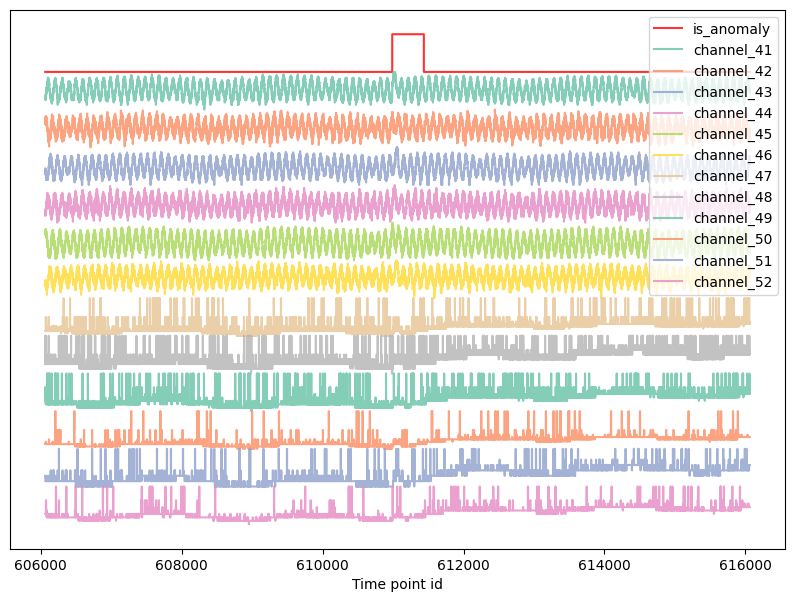

In [4]:
# Visualization of an example anomaly from the training set
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
plt.rcParams["image.cmap"] = "Set2"
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set2.colors)
plt.figure(figsize=(10,7))

start_idx = 606062
end_idx = start_idx + 10000

plt.step(train_df.loc[start_idx:end_idx, "id"], train_df.loc[start_idx:end_idx, "is_anomaly"] + 1, alpha=0.8, label="is_anomaly", where="post", color="red")

for i, channel in enumerate(channel_names):
    d = train_df.loc[start_idx:end_idx, channel]
    d = (d - np.min(d))/(np.max(d) - np.min(d))

    plt.step(train_df.loc[start_idx:end_idx, "id"], d - i, alpha=0.8, label=channel, where="post")

plt.xlabel("Time point id")
plt.yticks([], [])
plt.legend(loc="upper right")

In [9]:
len(train_df)

14728321